# Astrophysical injection and recovery

Generate the three complete spectral classes, inspect example realizations, and run a small end-to-end calibration experiment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from asterodetect import (
    AsteroScaleSamples, AstrophysicalInjectionFactory, Detector, NuisancePrior,
    ObservationModel, build_injection_grid, evaluate_injections,
)
from asterodetect.asteroscale import ASTERO_SCALE_PARAMETERS

In [6]:
n = 512
rng = np.random.default_rng(3)
values = {name: np.ones(n) for name in ASTERO_SCALE_PARAMETERS}
values.update(
    numax=rng.normal(1000.0, 2.0, n), dnu=rng.normal(100.0, 0.2, n),
    FWHM_env=rng.normal(250.0, 2.0, n), A_env=rng.lognormal(np.log(3.0), 0.1, n),
    A_gran=rng.lognormal(np.log(8.0), 0.1, n),
    b_gran_low=rng.normal(30.0, 1.0, n), b_gran_high=rng.normal(90.0, 2.0, n),
)
samples = AsteroScaleSamples(values)
factory = AstrophysicalInjectionFactory(samples, duration_days=27.4, cadence_seconds=120.0)

The injected oscillation spectrum contains individual modes. The detector receives only the realized periodogram and stellar constraints, not the generating model.

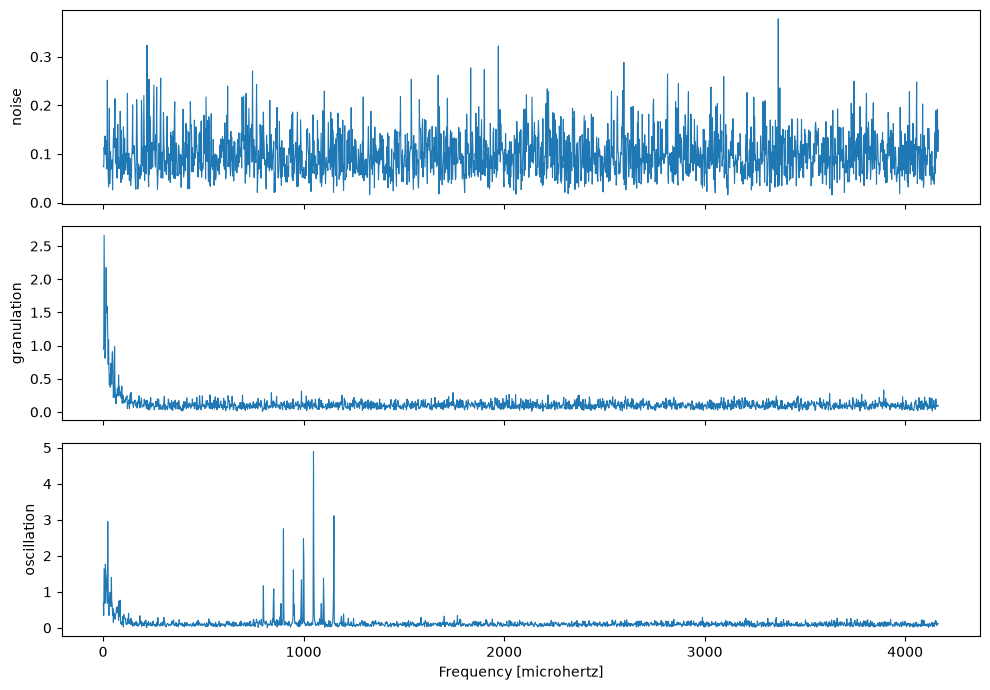

In [7]:
examples = build_injection_grid(
    {'truth': ['noise', 'granulation', 'oscillation'], 'amplitude_scale': [1.0]},
    factory, seed=10,
)
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, case in zip(axes, examples):
    display = case.spectrum.bin_by_width(2.0)
    ax.plot(display.frequency, display.power, lw=0.8)
    ax.set_ylabel(case.truth)
axes[-1].set_xlabel('Frequency [microhertz]')
plt.tight_layout();

In [8]:
# Keep this small for a tutorial; scientific calibration needs many more repeats and draws.
cases = build_injection_grid(
    {'truth': ['noise', 'granulation', 'oscillation'],
     'white_noise': [0.1, 0.5], 'amplitude_scale': [0.3, 1.0]},
    factory, repeats=2, seed=42,
)
detector = Detector(
    draws=256,
    observation=ObservationModel(integration_time_seconds=120.0),
    nuisance_prior=NuisancePrior(),
)
calibration = evaluate_injections(detector, cases, seed=43)
calibration.confusion_matrix, calibration.accuracy, calibration.multiclass_brier_score

(array([[8, 0, 0],
        [0, 8, 0],
        [0, 4, 4]]),
 0.8333333333333334,
 0.30033825638706185)

In [9]:
for amplitude, result in calibration.group_by('amplitude_scale').items():
    print(f'amplitude scale={amplitude}: accuracy={result.accuracy:.3f}, Brier={result.multiclass_brier_score:.3f}')

amplitude scale=0.3: accuracy=0.667, Brier=0.601
amplitude scale=1.0: accuracy=1.000, Brier=0.000


For a scientific run, increase `repeats` and `draws`, inspect evidence effective sample sizes, and compare identical injections using detectors configured with $0.5$, $1$, and $2\Delta\nu$ bin widths.